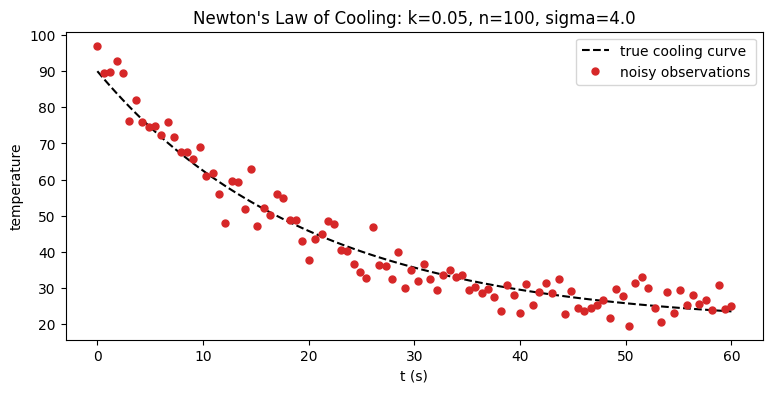

n=100, t range=[0.0, 60.0]


In [112]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

k_true = 0.05
x_env = 20.0
initial_temp = 90.0
sigma_obs = 4.0
n = 100
T = 60.0

def newton_cooling(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

rng = np.random.RandomState(0)
t_obs_np = np.linspace(0, T, n)
x_true_np = newton_cooling(k_true, x_env, initial_temp, t_obs_np)
y_obs_np = x_true_np + rng.normal(0, sigma_obs, size=n)

t_obs = torch.tensor(t_obs_np)
y_obs = torch.tensor(y_obs_np)

plt.figure(figsize=(9, 4))
plt.plot(t_obs_np, x_true_np, 'k--', label='true cooling curve')
plt.plot(t_obs_np, y_obs_np, '.', color='tab:red', markersize=10, label='noisy observations')
plt.xlabel('t (s)'); plt.ylabel('temperature'); plt.legend()
plt.title(f'Newton\'s Law of Cooling: k={k_true}, n={n}, sigma={sigma_obs}')
plt.show()

print(f"n={n}, t range=[{t_obs_np[0]:.1f}, {t_obs_np[-1]:.1f}]")

In [113]:
def rbf_kernel(t1, t2, sigma_f2, l):
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l**2)

In [114]:
def neg_log_marginal_likelihood_raw(sigma_f2, l, sigma2, t, y, jitter=1e-6):
    n = len(t)
    K = rbf_kernel(t, t, sigma_f2, l)
    C = K + sigma2 * torch.eye(n) + jitter * torch.eye(n)

    L = torch.linalg.cholesky(C)
    alpha = torch.cholesky_solve(y.unsqueeze(1), L).squeeze(1)

    data_fit = 0.5 * y @ alpha
    complexity = torch.log(torch.diagonal(L)).sum()
    const = 0.5 * n * np.log(2 * np.pi)

    return data_fit + complexity + const

In [115]:
from scipy.optimize import minimize

def loss_and_grad(params_np):
    sigma_f2 = torch.tensor(params_np[0], requires_grad=True)
    l = torch.tensor(params_np[1], requires_grad=True)
    sigma2 = torch.tensor(params_np[2], requires_grad=True)

    loss = neg_log_marginal_likelihood_raw(sigma_f2, l, sigma2, t_obs, y_obs)
    loss.backward()

    grad = np.array([sigma_f2.grad.item(), l.grad.item(), sigma2.grad.item()])
    return loss.item(), grad

bounds = [(0.01, 1e4), (1e-2, 1e2), (1e-3, 1e4)]
x0_opt = np.array([1.0, 10.0, sigma_obs**2])

result = minimize(loss_and_grad, x0_opt, method='L-BFGS-B', jac=True, bounds=bounds)

sigma_f2_star, l_star, sigma2_star = result.x
print(f"sigma_f^2* = {sigma_f2_star:.4f}")
print(f"l*         = {l_star:.4f}")
print(f"sigma^2*   = {sigma2_star:.4f}  (true noise variance = {sigma_obs**2:.4f})")
print(f"converged: {result.success}, final loss: {result.fun:.4f}")

sigma_f^2* = 10000.0000
l*         = 47.7290
sigma^2*   = 14.7530  (true noise variance = 16.0000)
converged: True, final loss: 291.4638


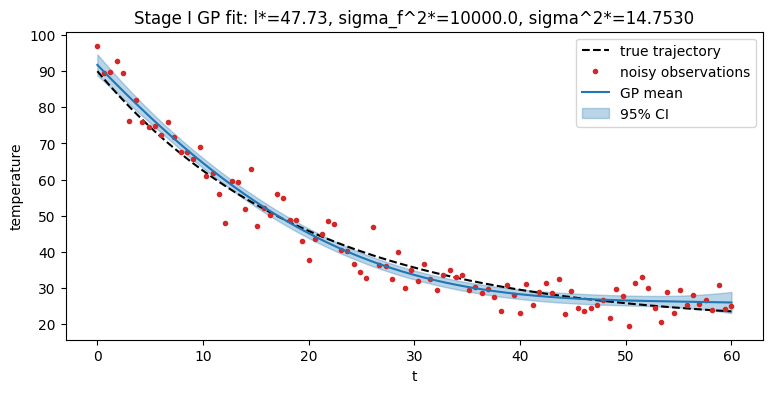

In [116]:
with torch.no_grad():
    sf2_t = torch.tensor(sigma_f2_star)
    l_t = torch.tensor(l_star)
    s2_t = torch.tensor(sigma2_star)

    K = rbf_kernel(t_obs, t_obs, sf2_t, l_t)
    C_mat = K + s2_t * torch.eye(n) + 1e-6 * torch.eye(n)
    L = torch.linalg.cholesky(C_mat)
    alpha = torch.cholesky_solve(y_obs.unsqueeze(1), L).squeeze(1)

    t_grid = torch.linspace(0, T, 300)
    k_star = rbf_kernel(t_grid, t_obs, sf2_t, l_t)
    mean_pred = k_star @ alpha

    v = torch.cholesky_solve(k_star.T, L)
    k_star_star = rbf_kernel(t_grid, t_grid, sf2_t, l_t)
    var_pred = torch.diagonal(k_star_star) - torch.sum(k_star * v.T, dim=1)
    std_pred = torch.sqrt(torch.clamp(var_pred, min=0))

plt.figure(figsize=(9, 4))
plt.plot(t_obs_np, x_true_np, 'k--', label='true trajectory')
plt.plot(t_obs_np, y_obs_np, '.', color='tab:red', label='noisy observations')
plt.plot(t_grid, mean_pred, color='tab:blue', label='GP mean')
plt.fill_between(t_grid, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred,
                  alpha=0.3, color='tab:blue', label='95% CI')
plt.xlabel('t'); plt.ylabel('temperature'); plt.legend()
plt.title(f"Stage I GP fit: l*={l_star:.2f}, sigma_f^2*={sigma_f2_star:.1f}, sigma^2*={sigma2_star:.4f}")
plt.show()

In [117]:
# freeze Stage I hyperparameters -- no gradient flows into them anymore
sigma_f2_star_t = torch.tensor(sigma_f2_star)
l_star_t = torch.tensor(l_star)
sigma2_star_t = torch.tensor(sigma2_star)

def gp_mean_fn(t_query, t_train, y_train, sigma_f2, l, sigma2, jitter=1e-6):
    n_train = len(t_train)
    K = rbf_kernel(t_train, t_train, sigma_f2, l)
    C = K + sigma2 * torch.eye(n_train) + jitter * torch.eye(n_train)
    L = torch.linalg.cholesky(C)
    alpha = torch.cholesky_solve(y_train.unsqueeze(1), L).squeeze(1)
    k_star = rbf_kernel(t_query, t_train, sigma_f2, l)
    return k_star @ alpha

t_query = t_obs.clone().detach().requires_grad_(True)

x_hat = gp_mean_fn(t_query, t_obs, y_obs, sigma_f2_star_t, l_star_t, sigma2_star_t)

xdot_hat = torch.autograd.grad(
    x_hat, t_query, grad_outputs=torch.ones_like(x_hat), create_graph=True
)[0]

x_hat = x_hat.detach()
xdot_hat = xdot_hat.detach()

print(x_hat.shape, xdot_hat.shape)

torch.Size([100]) torch.Size([100])


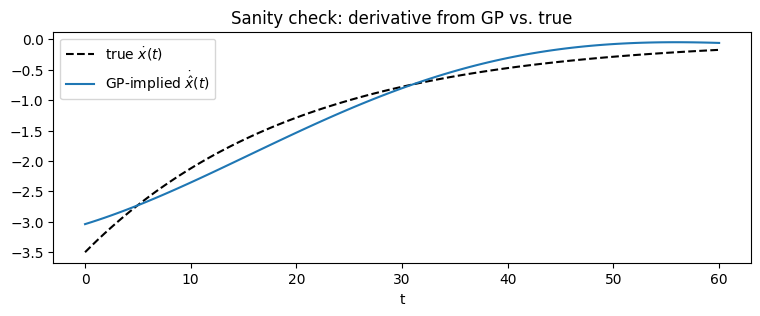

mean abs error: 0.17446
mean abs error relative to true amplitude: 0.191


In [118]:
def newton_cooling_deriv(k, x_env, x0, t):
    return -k * (x0 - x_env) * np.exp(-k * t)

xdot_true_np = newton_cooling_deriv(k_true, x_env, initial_temp, t_obs_np)

plt.figure(figsize=(9, 3))
plt.plot(t_obs_np, xdot_true_np, 'k--', label='true $\\dot{x}(t)$')
plt.plot(t_obs_np, xdot_hat.numpy(), color='tab:blue', label='GP-implied $\\dot{\\hat{x}}(t)$')
plt.legend(); plt.xlabel('t')
plt.title('Sanity check: derivative from GP vs. true')
plt.show()

resid = xdot_hat.numpy() - xdot_true_np
print(f"mean abs error: {np.mean(np.abs(resid)):.5f}")
print(f"mean abs error relative to true amplitude: {np.mean(np.abs(resid))/np.std(xdot_true_np):.3f}")

In [119]:
def g_n(k, x_hat, xdot_hat, x_env):
    r = xdot_hat + k * (x_hat - x_env)
    return torch.mean(r**2)

sigma_r2 = 0.05          # fixed constant, first pass -- same philosophy as MSD's Stage II
k_prior_mean = torch.tensor(0.03)
k_prior_var = torch.tensor(0.03**2)

def neg_log_posterior(k, x_hat, xdot_hat, x_env):
    gn = g_n(k, x_hat, xdot_hat, x_env)
    data_term = (n / (2 * sigma_r2)) * gn
    prior_term = 0.5 * (k - k_prior_mean)**2 / k_prior_var
    return data_term + prior_term

In [120]:
k_param = k_prior_mean.clone().detach().requires_grad_(True)
optimizer2 = torch.optim.LBFGS([k_param], lr=1.0, max_iter=200, line_search_fn='strong_wolfe')

def closure2():
    optimizer2.zero_grad()
    loss = neg_log_posterior(k_param, x_hat, xdot_hat, x_env)
    loss.backward()
    return loss

optimizer2.step(closure2)
k_map = k_param.detach()

print(f"k_MAP: {k_map.item():.4f}")
print(f"true:  {k_true:.4f}")

k_MAP: 0.0495
true:  0.0500


In [121]:
H = torch.autograd.functional.hessian(
    lambda kk: neg_log_posterior(kk, x_hat, xdot_hat, x_env), k_map
)
var_k = 1.0 / H.item()
std_k = np.sqrt(var_k)

print(f"k: {k_map.item():.4f} +/- {1.96*std_k:.4f} (95% CI)")
print(f"true k = {k_true}, inside CI: {abs(k_map.item()-k_true) < 1.96*std_k}")

k: 0.0495 +/- 0.0015 (95% CI)
true k = 0.05, inside CI: True


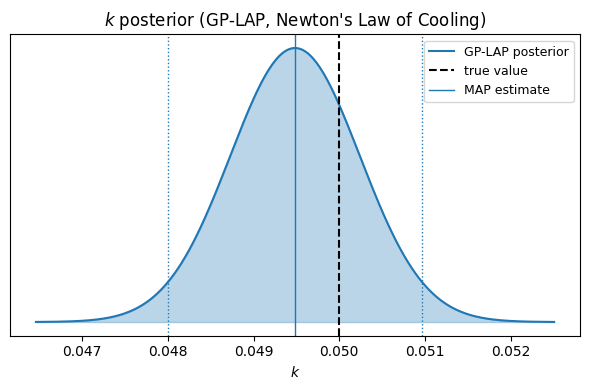

In [122]:
from scipy.stats import norm

mean_est = k_map.item()
std_est = std_k

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

k_grid = np.linspace(mean_est - 4*std_est, mean_est + 4*std_est, 300)
pdf = norm.pdf(k_grid, loc=mean_est, scale=std_est)

ax.plot(k_grid, pdf, color='tab:blue', label='GP-LAP posterior')
ax.fill_between(k_grid, pdf, alpha=0.3, color='tab:blue')

ci_lo, ci_hi = mean_est - 1.96*std_est, mean_est + 1.96*std_est
ax.axvline(ci_lo, color='tab:blue', linestyle=':', linewidth=1)
ax.axvline(ci_hi, color='tab:blue', linestyle=':', linewidth=1)

ax.axvline(k_true, color='k', linestyle='--', label='true value')
ax.axvline(mean_est, color='tab:blue', linestyle='-', linewidth=1, label='MAP estimate')

ax.set_title('$k$ posterior (GP-LAP, Newton\'s Law of Cooling)')
ax.set_xlabel('$k$')
ax.set_yticks([])
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [123]:
with torch.no_grad():
    gn_at_map = g_n(k_map, x_hat, xdot_hat, x_env)
    data_term = (n / (2*sigma_r2)) * gn_at_map
    prior_term = 0.5 * (k_map - k_prior_mean)**2 / k_prior_var

print(f"g_n(k_MAP) = {gn_at_map:.6f}")
print(f"data term:  {data_term.item():.4f}")
print(f"prior term: {prior_term.item():.4f}")

g_n(k_MAP) = 0.047539
data term:  47.5388
prior term: 0.2109
